### Install varseek, and import all packages

In [1]:
try:
    import varseek as vk
except ImportError:
    print("varseek not found, installing...")
    !pip install -U -q varseek

In [2]:
import os
import re
import anndata as ad
import pandas as pd
import pysam

import varseek as vk

In [3]:
# !pip install -q ipython-autotime
%load_ext autotime

time: 62 μs (started: 2026-08-10 11:41:35 -07:00)


# [vk denovo](https://github.com/pachterlab/varseek) on NA12878 (GIAB HG001) — benchmarked against ground truth

This notebook runs the **varseek de novo** pipeline (`vk denovo` → `vk ref` → `vk count`) on
**NA12878 / HG001** whole-genome sequencing reads, then compares the calls **directly to the
Genome in a Bottle (GIAB) HG001 v4.2.1 truth set** with `hap.py` — the standard germline
small-variant benchmarking tool.

**Scope: chromosome 20** (the canonical GIAB benchmarking chromosome), in the GIAB
high-confidence regions. This keeps the demo tractable while giving a real ground-truth
comparison.

**Data**
- Reads: GIAB NIST `RMNISTHS_30xdownsample.bam` (NA12878, ~30×), chr20 reads only, re-aligned to GRCh38.
- Reference: Ensembl GRCh38 primary assembly (already used by `vk_denovo.ipynb`).
- Truth: `HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz` + high-confidence `.bed`, restricted to chr20
  and renamed to Ensembl contig naming (`chr20` → `20`).

> Because the input is whole-genome **DNA** (not RNA), `vk denovo` aligns with **bowtie2**
> (DNA aligner) rather than STAR, and `vk count` runs in `bulk`/`paired` mode.


### Define paths and parameters

In [4]:
import os, re, gzip, subprocess
import numpy as np
import pandas as pd
import anndata as ad
import pysam

# ---- reference (shared with vk_denovo.ipynb) ----
reference_dir = os.path.join("data", "reference")
sequences = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.dna.primary_assembly.fa")
gtf = os.path.join(reference_dir, "ensembl_grch38_release114", "Homo_sapiens.GRCh38.114.gtf")

# ---- NA12878 chr20 working dir ----
root = os.path.join("data", "na12878_chr20")
reads_dir = os.path.join(root, "reads")
r1 = os.path.join(reads_dir, "NA12878_chr20_R1.fastq.gz")
r2 = os.path.join(reads_dir, "NA12878_chr20_R2.fastq.gz")
chr20_bam = os.path.join(reads_dir, "chr20.bam")

bowtie2_index_prefix = os.path.join(reference_dir, "bowtie2_chr20", "chr20")

# vk denovo out
variants_dir = os.path.join(root, "varseek_denovo_out")
variants_vcf = os.path.join(variants_dir, "variants.vcf.gz")
variants = os.path.join(variants_dir, "variants.tsv")
denovo_bam_dir = os.path.join(variants_dir, "bams")

# vk ref out
vk_ref_out_dir = os.path.join(root, "varseek_ref_out")
vcrs_index = os.path.join(vk_ref_out_dir, "vcrs_index_denovo.idx")
vcrs_t2g = os.path.join(vk_ref_out_dir, "vcrs_t2g_denovo.txt")

# vk count out
vk_count_out_dir = os.path.join(root, "varseek_count_out")
vk_count_variants_vcf = os.path.join(vk_count_out_dir, "varseek_variants.vcf")

# GIAB truth
giab_dir = os.path.join(root, "giab")
truth_vcf = os.path.join(giab_dir, "truth_chr20_ens.vcf.gz")
confident_bed = os.path.join(giab_dir, "confident_chr20_ens.bed")

# hap.py out
happy_out = os.path.join(root, "happy_output")

# general parameters
k = 41
w = k - 1
min_counts_denovo = 3          # vk denovo: min reads supporting a candidate (INFO/AO)
min_counts_clean = 1           # vk clean: per-entry floor (no-op here; see the recount cell)
min_supporting_reads = 3       # vk count: min reads compatible with a VCRS to call it detected
threads = 32
read_length = 148

denovo_min_mapq = 20
denovo_min_baseq = 20
denovo_min_vaf = 0.20

time: 5.57 ms (started: 2026-08-10 11:41:35 -07:00)


In [5]:
# --- Tool runtime recording -------------------------------------------------
# Every tool below (vk denovo / vk ref / vk count / DeepVariant / GATK
# HaplotypeCaller / GATK Mutect2) is timed, and its wall-clock runtime in
# seconds is written to `tool_runtimes.json` *immediately* after it finishes.
# Persisting to disk means a recorded time is not forgotten across kernel
# restarts, and is not lost when a later cell re-runs and skips the tool via an
# `if not os.path.exists(...)` guard (in that case the previously recorded time
# is simply kept). The three varseek stages are stored separately here for
# reference; the runtime plot at the end sums them into one "varseek" bar.
import json, time
from contextlib import contextmanager

runtime_json = os.path.join(root, "tool_runtimes.json")

def load_runtimes():
    if os.path.exists(runtime_json):
        with open(runtime_json) as fh:
            return json.load(fh)
    return {}

def save_runtime(name, seconds):
    data = load_runtimes()
    data[name] = seconds
    os.makedirs(os.path.dirname(runtime_json), exist_ok=True)
    with open(runtime_json, "w") as fh:
        json.dump(data, fh, indent=2, sort_keys=True)
    print(f"[runtime] {name}: {seconds:.1f} s ({seconds/60:.2f} min)  ->  {runtime_json}")

@contextmanager
def record_runtime(name):
    _t0 = time.perf_counter()
    try:
        yield
    finally:
        save_runtime(name, time.perf_counter() - _t0)

print(f"Runtimes will be written to: {runtime_json}")
print("Existing recorded runtimes:", load_runtimes())

Runtimes will be written to: data/na12878_chr20/tool_runtimes.json
Existing recorded runtimes: {'deepvariant': 941.5780808329582, 'haplotypecaller': 1727.4541525095701, 'mutect2': 1306.6620010212064, 'strelka2': 159.10879575833678, 'varscan': 790.2433219850063, 'vk count': 121.22591537982225, 'vk count (COSMIC)': 370.3193492665887, 'vk denovo': 8.753541897982359, 'vk ref': 148.98322872817516, 'vk ref (COSMIC)': 397.63909078761935}
time: 17.4 ms (started: 2026-08-10 11:41:35 -07:00)


In [6]:
if not os.path.exists(sequences):
    sequences_dir = os.path.dirname(sequences)
    !gget ref -w dna -r 114 --out_dir {sequences_dir} -d human
    !gunzip {sequences}.gz

if not os.path.exists(gtf):
    gtf_dir = os.path.dirname(gtf)
    !gget ref -w gtf -r 114 --out_dir {gtf_dir} -d human
    !gunzip {gtf}.gz

time: 15.5 ms (started: 2026-08-10 11:41:35 -07:00)


### Download NA12878 chr20 reads (GIAB 30× BAM) and re-align target

We stream only the **chr20** reads from the GIAB NIST 30× downsampled NA12878 BAM, then convert
them to paired FASTQ. Reads are reference-agnostic, so although that BAM is GRCh37-aligned we
re-align to GRCh38 below.

In [ ]:
GIAB_30X_BAM = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/data/NA12878/"
                "NIST_NA12878_HG001_HiSeq_300x/RMNISTHS_30xdownsample.bam")

os.makedirs(reads_dir, exist_ok=True)
if not (os.path.exists(r1) and os.path.exists(r2)):
    if not os.path.exists(chr20_bam):
        subprocess.run(["samtools", "view", "-@", str(threads), "-b", GIAB_30X_BAM, "20",
                        "-o", chr20_bam], check=True)
    # collate into read pairs, then emit paired FASTQ (singletons dropped)
    collate = subprocess.Popen(["samtools", "collate", "-@", str(threads), "-u", "-O",
                                chr20_bam, os.path.join(reads_dir, "collate_tmp")],
                               stdout=subprocess.PIPE)
    subprocess.run(["samtools", "fastq", "-@", str(threads), "-1", r1, "-2", r2,
                    "-0", "/dev/null", "-s", os.path.join(reads_dir, "singletons.fastq.gz"),
                    "-n", "-"], stdin=collate.stdout, check=True)
    collate.wait()

# n_pairs = sum(1 for _ in gzip.open(r1, "rt")) // 4
# print(f"NA12878 chr20 read pairs: {n_pairs:,}")


NA12878 chr20 read pairs: 6,633,667
time: 16.7 s (started: 2026-08-10 11:41:35 -07:00)


### Build a chr20 bowtie2 index

`vk denovo` aligns DNA reads with bowtie2. The reads were extracted from chr20, so a chr20 index
suffices and is fast to build.

In [8]:
bt2_dir = os.path.dirname(bowtie2_index_prefix)
os.makedirs(bt2_dir, exist_ok=True)
if not os.path.exists(bowtie2_index_prefix + ".1.bt2"):
    chr20_fa = bowtie2_index_prefix + ".fa"
    subprocess.run(f"samtools faidx {sequences} 20 > {chr20_fa}", shell=True, check=True)
    subprocess.run(["bowtie2-build", "--threads", str(threads), chr20_fa, bowtie2_index_prefix],
                   check=True)
print("bowtie2 chr20 index ready:", bowtie2_index_prefix)


bowtie2 chr20 index ready: data/reference/bowtie2_chr20/chr20
time: 1.85 ms (started: 2026-08-10 11:41:51 -07:00)


### Prepare the GIAB ground-truth VCF and high-confidence BED (chr20, Ensembl naming)

The GIAB truth uses UCSC contig names (`chr20`); our reference uses Ensembl naming (`20`). We
subset to chr20, rename, and left-normalize the truth against the reference. The high-confidence
BED defines where the benchmark is valid — both `vk denovo` calling and `hap.py` evaluation are
restricted to it.

In [9]:
os.makedirs(giab_dir, exist_ok=True)
GIAB_REL = ("https://ftp-trace.ncbi.nlm.nih.gov/ReferenceSamples/giab/release/"
            "NA12878_HG001/NISTv4.2.1/GRCh38")
raw_vcf = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.vcf.gz")
raw_bed = os.path.join(giab_dir, "HG001_GRCh38_v4.2.1_benchmark.bed")

if not os.path.exists(truth_vcf):
    if not os.path.exists(raw_vcf):
        subprocess.run(["curl", "-sL", "-o", raw_vcf,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz"], check=True)
        subprocess.run(["curl", "-sL", "-o", raw_vcf + ".tbi",
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.vcf.gz.tbi"], check=True)
    rename = os.path.join(giab_dir, "rename_chr20.txt")
    with open(rename, "w") as fh:
        fh.write("chr20\t20\n")
    p1 = subprocess.Popen(["bcftools", "view", "-r", "chr20", raw_vcf, "-Ou"], stdout=subprocess.PIPE)
    p2 = subprocess.Popen(["bcftools", "annotate", "--rename-chrs", rename, "-Ou"],
                          stdin=p1.stdout, stdout=subprocess.PIPE); p1.stdout.close()
    subprocess.run(["bcftools", "norm", "-f", sequences, "-m", "-both", "-Oz", "-o", truth_vcf],
                   stdin=p2.stdout, check=True); p2.stdout.close(); p1.wait(); p2.wait()
    subprocess.run(["bcftools", "index", "-t", "-f", truth_vcf], check=True)

if not os.path.exists(confident_bed):
    if not os.path.exists(raw_bed):
        subprocess.run(["curl", "-sL", "-o", raw_bed,
                        f"{GIAB_REL}/HG001_GRCh38_1_22_v4.2.1_benchmark.bed"], check=True)
    subprocess.run("awk -F'\t' '$1==\"chr20\"{sub(/^chr/,\"\",$1);print}' OFS='\t' "
                   f"{raw_bed} > {confident_bed}", shell=True, check=True)

print("truth variants (chr20):", subprocess.run(["bcftools", "view", "-H", truth_vcf],
      capture_output=True, text=True).stdout.count("\n"))
print("confident intervals (chr20):", sum(1 for _ in open(confident_bed)))


truth variants (chr20): 83629
confident intervals (chr20): 13529
time: 348 ms (started: 2026-08-10 11:41:51 -07:00)


In [ ]:
# =========================================================================
# Recount the VCRS matrix from the BUS file, multimapping-aware.
#
# kb count finishes with `bustools count --genecounts --multimapping --cm`, and that path
# divides a multimapped read's count by the size of its equivalence class *in integer
# arithmetic*. With --num every read carries the same placeholder UMI, so `bustools sort`
# first collapses all reads sharing an EC into one record; the matrix entry a VCRS then
# receives is exactly
#
#       sum over ECs containing it of  floor(reads_in_EC / targets_in_EC)
#
# (verified bit-exact against cells_x_genes.mtx below). Any VCRS whose reads only ever land
# in equivalence classes with fewer reads than targets therefore gets a hard **0** -- not a
# small number, zero -- and is dropped by the `sum > 0` filter downstream. On this run that
# silently deleted 2,471 VCRSs that did have reads, 605 of them real GIAB variants.
#
# The fix is to stop dividing: a read that is compatible with a VCRS is evidence for that
# VCRS. We recount as `sum of reads over all ECs containing the VCRS` and then require
# `min_supporting_reads` of them, which is a threshold on evidence rather than an artefact of
# integer division. (Splitting fractionally instead gives the identical *detected* set -- any
# positive fraction is still positive -- but a worse precision/recall curve once thresholded.)
# =========================================================================
import collections
from kb_python.config import get_bustools_binary_path


def vcrs_read_counts(kb_dir, var_names):
    """Reads compatible with each VCRS, from the raw BUS file. Returns an array aligned to var_names."""
    ec = {}
    for line in open(os.path.join(kb_dir, "matrix.ec")):
        ec_id, targets = line.rstrip("\n").split("\t")
        ec[int(ec_id)] = np.fromstring(targets, dtype=int, sep=",")

    bus_txt = os.path.join(kb_dir, "output.bus.txt")
    if not os.path.exists(bus_txt):
        subprocess.run([str(get_bustools_binary_path()), "text", "-o", bus_txt,
                        os.path.join(kb_dir, "output.bus")], check=True)

    reads_per_ec = collections.Counter()
    with open(bus_txt) as fh:
        for line in fh:
            _bc, _umi, ec_id, count = line.split("\t")
            reads_per_ec[int(ec_id)] += int(count)

    counts = np.zeros(len(var_names))
    for ec_id, n in reads_per_ec.items():
        counts[ec[ec_id]] += n
    return counts

VCRSs in the index                          : 101,804
  detected by bustools (floor(reads/|EC|))  : 94,223
  with >=1 compatible read (recount)        : 96,246   (+2,023 zeroed by integer division)
  with >=3 compatible reads (called)      : 95,351
time: 3.6 s (started: 2026-08-10 11:41:52 -07:00)


Convert the varseek AnnData call matrix to a sites-only VCF (same helper as `vk_denovo.ipynb`).

In [ ]:
def adata_to_vcf(adata, vcf_out, counts=None, min_reads=1):
    """Sites-only VCF of every VCRS with at least `min_reads` supporting reads.

    `counts` overrides the AnnData matrix (see the recount cell); pass None to threshold on
    the matrix column sums, which is what `vk_denovo.ipynb` does."""
    if os.path.exists(vcf_out):
        print(f"{vcf_out} already exists, skipping VCF writing.")
        return
    if isinstance(adata, str):
        adata = ad.read_h5ad(adata)
    if counts is None:
        counts = np.asarray(adata.X.sum(axis=0)).ravel()
    adata = adata[:, np.asarray(counts) >= min_reads]
    variants = adata.var_names.tolist()
    fasta = pysam.FastaFile(sequences)
    chromosomes = {str(i) for i in range(1, 23)}.union({"X", "Y", "MT"})

    var_series = pd.Series(variants, dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    for var in var_series[~(snv_mask | ins_mask | del_mask)]:
        print(f"Could not parse: {var}")

    frames = []
    snv = snv[snv_mask & snv["CHROM"].isin(chromosomes)]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}, index=snv.index))
    ins = ins[ins_mask & ins["CHROM"].isin(chromosomes)]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}, index=ins.index))
    dele = dele[del_mask & dele["CHROM"].isin(chromosomes)]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}, index=dele.index))

    vcf_df = pd.concat(frames).sort_index() if frames else pd.DataFrame(columns=["CHROM","POS","REF","ALT"])
    lines = (vcf_df["CHROM"].astype(str) + "\t" + vcf_df["POS"].astype(str) + "\t.\t"
             + vcf_df["REF"] + "\t" + vcf_df["ALT"] + "\t.\t.\t.\n")
    with open(vcf_out, "w") as f:
        f.write("##fileformat=VCFv4.2\n")
        f.write("#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        f.write("".join(lines))
    print(f"Wrote {len(vcf_df):,} variants to {vcf_out}")

data/na12878_chr20/varseek_count_out/varseek_variants.vcf already exists, skipping VCF writing.
time: 3.26 ms (started: 2026-08-10 11:41:56 -07:00)


### Direct comparison to GIAB ground truth with `hap.py`

Because NA12878 has a gold-standard truth set, this is a **direct** benchmark (no need for a
proxy caller): GIAB is the **truth**, the varseek calls are the **query**, evaluated inside the
high-confidence regions on chr20.

- **Recall** = fraction of true chr20 variants (in confident regions) that varseek recovered.
- **Precision** = fraction of varseek calls that are real.

Recall is bounded by sequencing coverage and by `min_counts` thresholds; precision is the headline
quality metric.

In [ ]:
def ensure_genotype_column(vcf_path, sample_name="VARSEEK", genotype="1/1"):
    """varseek emits a sites-only VCF; hap.py needs a sample column with a GT."""
    open_func = gzip.open if vcf_path.endswith(".gz") else open
    with open_func(vcf_path, "rt") as f:
        lines = f.readlines()
    for line in lines:
        if line.startswith("#CHROM"):
            if len(line.rstrip("\n").split("\t")) > 8:
                return
            break
    gt_header = '##FORMAT=<ID=GT,Number=1,Type=String,Description="Genotype">\n'
    out, inserted = [], False
    for line in lines:
        if line.startswith("##"):
            out.append(line)
        elif line.startswith("#CHROM"):
            if not inserted:
                out.append(gt_header); inserted = True
            out.append("\t".join(line.rstrip("\n").split("\t") + ["FORMAT", sample_name]) + "\n")
        elif line.strip():
            out.append("\t".join(line.rstrip("\n").split("\t") + ["GT", genotype]) + "\n")
    with open(vcf_path, "wt") as f:
        f.writelines(out)


def normalize_query(query_vcf, reference_fasta):
    """reheader (add contig lines) -> left-normalize/split -> sort -> inject GT -> bgzip+index."""
    out = query_vcf.replace(".vcf", "_normalized.vcf")
    if not out.endswith(".gz"):
        out += ".gz"
    fai = f"{reference_fasta}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", reference_fasta], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, query_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", reference_fasta, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", out], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    ensure_genotype_column(out)
    with open(out, "rb") as fh:
        is_gzip = fh.read(2) == b"\x1f\x8b"
    if not is_gzip:  # ensure_genotype_column rewrote it as plain text
        subprocess.run(f"mv {out} {out}.tmp && bgzip -c {out}.tmp > {out} && rm {out}.tmp",
                       shell=True, check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", out], check=True)
    return out

Writing to /home/jrich/tmp/bcftools.3eG5SD
Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	95608/0/0/0/0/0/0
Merging 1 temporary files
Done
Cleaning


hap.py summary: data/na12878_chr20/happy_output/varseek_vs_giab_truth.summary.csv
time: 702 ms (started: 2026-08-10 11:41:56 -07:00)


varseek de novo — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=66,734   FP=  938   FN= 2,476   precision=98.6%, recall=96.4%
  INDEL  TP= 9,647   FP=   64   FN=   857   precision=99.3%, recall=91.8%
  ALL    TP=76,381   FP=1,002   FN= 3,333   precision=98.7%, recall=95.8%


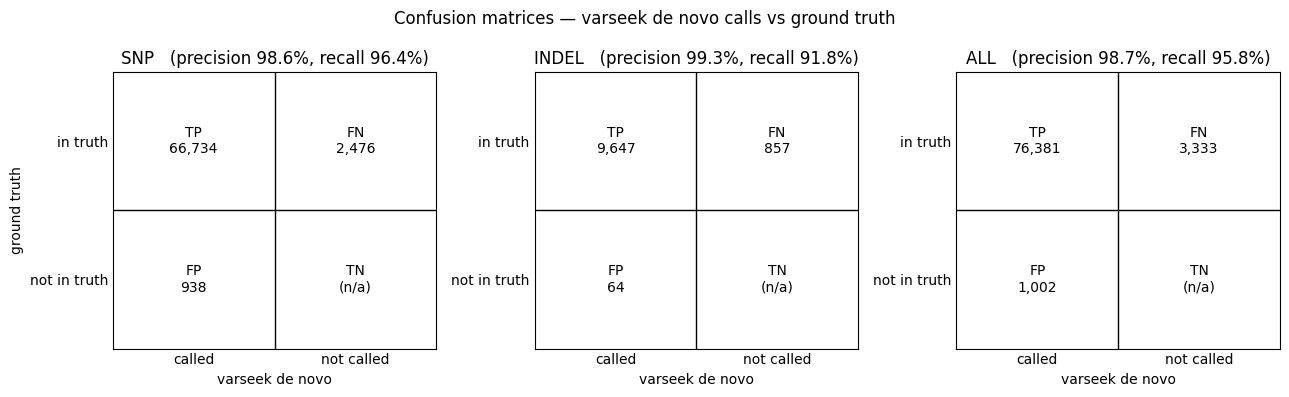

time: 183 ms (started: 2026-08-10 11:41:56 -07:00)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def happy_confusion_counts(summary_csv):
    """{type: (TP, FP, FN)} straight from a hap.py summary CSV (PASS rows), plus an
    ALL row summing SNP + INDEL.  TP/FN are truth-side, FP is query-side."""
    summ = pd.read_csv(summary_csv)
    summ = summ[summ["Filter"] == "PASS"].set_index("Type")
    cms = {t: (int(summ.loc[t, "TRUTH.TP"]), int(summ.loc[t, "QUERY.FP"]), int(summ.loc[t, "TRUTH.FN"]))
           for t in ("SNP", "INDEL")}
    cms["ALL"] = tuple(sum(v) for v in zip(cms["SNP"], cms["INDEL"]))
    return cms


def plot_confusion_matrices(summary_csv, tool="varseek", verbose=True):
    """Plain, color-free SNP / INDEL / ALL confusion matrices for one tool's hap.py run.
    The false-negative cell is printed but the TN cell is n/a (unbounded), so the
    matrices are read as: which of this tool's calls are real, and what did it miss."""
    cms = happy_confusion_counts(summary_csv)

    if verbose:
        print(f"{tool} — confusion counts (FN shown for reference, excluded from the matrices):")
        for name, (tp, fp, fn) in cms.items():
            print(f"  {name:5s}  TP={tp:>6,}   FP={fp:>5,}   FN={fn:>6,}   "
                  f"precision={tp/(tp+fp):.1%}, recall={tp/(tp+fn):.1%}")

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (name, (tp, fp, fn)) in zip(axes, cms.items()):
        # rows = GIAB truth (in / not in), cols = the tool's call (called / not called).
        # FN (in-truth & not-called) is shown; TN (not-truth & not-called) is excluded.
        cells = [[f"TP\n{tp:,}", f"FN\n{fn:,}"],
                 [f"FP\n{fp:,}", "TN\n(n/a)"]]
        for i in range(2):
            for j in range(2):
                ax.text(j, i, cells[i][j], ha="center", va="center", fontsize=10, color="black")
        ax.set_xlim(-0.5, 1.5); ax.set_ylim(1.5, -0.5)   # row 0 at top
        ax.axhline(0.5, color="black", lw=1); ax.axvline(0.5, color="black", lw=1)
        ax.set_xticks([0, 1]); ax.set_xticklabels(["called", "not called"])
        ax.set_yticks([0, 1]); ax.set_yticklabels(["in truth", "not in truth"])
        ax.tick_params(length=0)
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color("black")
        ax.set_title(f"{name}   (precision {tp/(tp+fp):.1%}, recall {tp/(tp+fn):.1%})")
        ax.set_xlabel(tool)
    axes[0].set_ylabel("ground truth")
    fig.suptitle(f"Confusion matrices — {tool} calls vs ground truth")
    plt.tight_layout(); plt.show()
    return cms


In [ ]:
max_homopolymer_length = 7
min_unique_triplets = 25, 30, 32, 34
w = 31
k = 41
remove_alignment_to_reference = False  #!!! change
pseudobam_validation = True  #!!! change
check_alignment_position = True  #!!! change

# ---- COSMIC genotyping-mode paths and parameters ----
# The catalog reference is genome-wide (COSMIC is not chr20-specific); the reads are chr20, and
# hap.py scopes the evaluation to chr20 confident regions exactly as it does for the de novo run.
cosmic_tsv = os.path.join("data", "cosmic", "Cosmic_MutantCensus_v104_GRCh38.tsv")

# NOTE: the filter-combination cell above rebinds the global `root` to
# data/na12878_chr20/varseek_parameter_tests, so anchor these outputs to an explicit base
# directory instead of to whatever `root` happens to point at by now.
na12878_root = os.path.join("data", "na12878_chr20")

# vk ref out (COSMIC catalog)
vk_ref_out_dir_cosmic = os.path.join(na12878_root, "varseek_ref_out_cosmic_k41_w31")  #!!! change
vcrs_index_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_index_cosmic.idx")
vcrs_t2g_cosmic = os.path.join(vk_ref_out_dir_cosmic, "vcrs_t2g_cosmic.txt")

# vk count out (COSMIC screen)
vk_count_out_dir_cosmic = os.path.join(na12878_root, "varseek_count_out_cosmic_pseudobam_position_k41_w31")  #!!! change
vk_count_variants_vcf_cosmic = os.path.join(vk_count_out_dir_cosmic, "varseek_variants.vcf")

# COSMIC catalog as VCF + the COSMIC-restricted GIAB truth built from it
cosmic_sites_vcf = os.path.join(giab_dir, "cosmic_chr20_sites.vcf")
cosmic_norm_vcf = os.path.join(giab_dir, "cosmic_chr20_normalized.vcf.gz")
truth_vcf_cosmic = os.path.join(giab_dir, "truth_chr20_ens_cosmic_only.vcf.gz")

# hap.py
prefix = os.path.join(os.path.abspath(happy_out), "varseek_cosmic_vs_giab_truth_pseudobam_position_k41_w31")  #!!! change
summary_csv_cosmic = f"{prefix}.summary.csv"

# reference genome index for pseudobam validation (chr20 only)
reference_genome_index_dir = os.path.join(na12878_root, "kb_ref")
reference_genome_index = os.path.join(reference_genome_index_dir, "index.idx")
reference_genome_t2g = os.path.join(reference_genome_index_dir, "t2g.txt")
reference_genome_f1 = os.path.join(reference_genome_index_dir, "f1.fa")
reference_bam = f"{na12878_root}/varseek_denovo_out/bams/NA12878_chr20_R1_aligned_to_Homo_sapiens_GRCh38_dna_primary_assembly.bam"

threads = 32

os.makedirs(vk_ref_out_dir_cosmic, exist_ok=True)
os.makedirs(vk_count_out_dir_cosmic, exist_ok=True)
os.makedirs(reference_genome_index_dir, exist_ok=True)
print("COSMIC catalog:", cosmic_tsv)

COSMIC catalog: data/cosmic/Cosmic_MutantCensus_v104_GRCh38.tsv
time: 2.15 ms (started: 2026-08-10 11:41:56 -07:00)


In [19]:
# vk ref reads the catalog as a table of (seq_id, variant) HGVS parts; COSMIC ships the two
# glued together in HGVSG ("20:g.31022441C>T"), so split them once and cache the result in the TSV.
if not os.path.exists(cosmic_tsv):
    raise FileNotFoundError(f"Cosmic TSV not found at {cosmic_tsv}; please download from https://cancer.sanger.ac.uk/cosmic/download/cosmic/v104/mutantcensus.")

cosmic_tsv_cols = pd.read_csv(cosmic_tsv, sep="\t", nrows=0).columns
if "seq_id" not in cosmic_tsv_cols or "variant" not in cosmic_tsv_cols:
    cosmic_df = pd.read_csv(cosmic_tsv, sep="\t", low_memory=False)
    cosmic_df[["seq_id", "variant"]] = cosmic_df["HGVSG"].str.split(":", n=1, expand=True)
    cosmic_df.to_csv(cosmic_tsv, sep="\t", index=False)
    print(f"Added seq_id/variant columns to {cosmic_tsv} ({len(cosmic_df):,} records)")
else:
    print("COSMIC TSV already carries seq_id/variant columns")

COSMIC TSV already carries seq_id/variant columns
time: 17.5 ms (started: 2026-08-10 11:41:56 -07:00)


In [ ]:
# Build the VCRS reference from the whole COSMIC census. Two settings are deliberately the
# same as the de novo build above so the two modes stay comparable:
#   * w = k - 1. A shorter flank means any second variant within (k-1-w) bp of the first leaves
#     no clean variant k-mer, and that VCRS can never be hit.
#   * remove_alignment_to_reference=False -- no d-list. `species="human"` is NOT passed: it makes
#     vk ref d-list against T2T while we call against GRCh38, which strips genuine variants
#     (see the d-list discussion above).
if not os.path.exists(vcrs_index_cosmic):
    with record_runtime("vk ref (COSMIC)"):
        vk_ref_output_dict_cosmic = vk.ref(
            variants=cosmic_tsv,
            sequences=sequences,
            seq_id_column="seq_id",
            var_column="variant",
            remove_alignment_to_reference=remove_alignment_to_reference,
            species="human",
            out=vk_ref_out_dir_cosmic,
            reference_out_dir=reference_dir,
            vcrs_unfiltered_fasta_out=os.path.join(vk_ref_out_dir_cosmic, "vcrs_unfiltered.fa"),
            save_variants_updated_dataframe=False,
            index_out=vcrs_index_cosmic,
            vcrs_t2g_out=vcrs_t2g_cosmic,
            w=w,
            k=k,
            max_homopolymer_length=max_homopolymer_length,
            min_unique_triplets=min_unique_triplets,
            threads=threads,
        )
print("COSMIC VCRS index:", vcrs_index_cosmic)
print("VCRSs in the COSMIC reference:", sum(1 for _ in open(vcrs_t2g_cosmic)))

11:41:57 - INFO - Using COSMIC email from COSMIC_EMAIL environment variable
11:41:57 - INFO - Using COSMIC password from COSMIC_PASSWORD environment variable


/home/jrich/Desktop/varseek-fresh/varseek/varseek_build.py:772: DtypeWarning: Columns (14,26) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv(mutations, sep="\t")
11:42:56 - INFO - add_gene_name_to_header is set, but no GTF path was provided; leaving headers without gene-name annotations.
11:42:56 - INFO - Using the seq_id_column:var_column 'seq_id:variant' columns as the variant header column.
11:43:16 - INFO - Removing 110 duplications > k
11:44:17 - INFO - Unfiltered (pre-filter, pre-merge) VCRS fasta written to data/na12878_chr20/varseek_ref_out_cosmic_k41_w31/vcrs_unfiltered.fa.
/home/jrich/Desktop/varseek-fresh/varseek/varseek_build.py:1257: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mu

[runtime] vk ref (COSMIC): 342.9 s (5.72 min)  ->  data/na12878_chr20/tool_runtimes.json
COSMIC VCRS index: data/na12878_chr20/varseek_ref_out_cosmic_k41_w31/vcrs_index_cosmic.idx
VCRSs in the COSMIC reference: 1448915
time: 5min 43s (started: 2026-08-10 11:41:57 -07:00)


In [21]:
# Screen the same paired NA12878 chr20 reads against the COSMIC index. Bulk DNA mode
# (technology="dna", parity="paired"), identical to the de novo vk count call above --
# only the reference differs.
adata_path_cosmic = os.path.join(vk_count_out_dir_cosmic, "adata_cleaned.h5ad")
if not os.path.exists(adata_path_cosmic):
    # if pseudobam_validation and not os.path.exists(reference_genome_index):
    #     !kb ref -i {reference_genome_index} -g {reference_genome_t2g} -f1 {reference_genome_f1} -k {k} -t {threads} {sequences} {gtf}
    with record_runtime("vk count (COSMIC)"):
        vk_count_output_dict_cosmic = vk.count(
            [r1, r2],
            index=vcrs_index_cosmic,
            t2g=vcrs_t2g_cosmic,
            technology="dna",
            parity="paired",
            out=vk_count_out_dir_cosmic,
            k=k,
            threads=threads,
            strand="unstranded",
            min_counts=min_counts_clean,
            pseudobam_validation=pseudobam_validation,
            reference_bam=reference_bam,
            check_alignment_position=check_alignment_position,
            # reference_genome_index=reference_genome_index
        )
    adata_path_cosmic = vk_count_output_dict_cosmic["adata_path"]
print("adata:", adata_path_cosmic)

11:47:40 - INFO - parity='paired' and parity_kb_count='single'. This means that kb count will run in single-end mode on this paired-end data, which will enable different pairs to be processed independently and thus potentially detect different variants. To turn this feature off, set parity_kb_count='paired'.
11:47:40 - INFO - Error sorting fastq files: File data/na12878_chr20/reads/NA12878_chr20_R1.fastq.gz does not match the expected bulk file naming convention of SAMPLE_PAIR.EXT where SAMPLE is sample name, PAIR is 1/2, and EXT is a fastq extension - or the Illumina file naming convention of SAMPLE_LANE_R[12]_001.fastq.gz, where SAMPLE is letters, numbers, underscores; LANE is numbers with optional leading 0s; pair is either R1 or R2; and it has .fq or .fastq extension (or .fq.gz or .fastq.gz).
Raising exception and exiting because sort_fastqs=True, which requires standard bulk or Illumina file naming convention. Please check fastq file names or set sort_fastqs=False.. Returning unso

[runtime] vk count (COSMIC): 441.9 s (7.36 min)  ->  data/na12878_chr20/tool_runtimes.json
adata: /home/jrich/Desktop/varseek-examples/data/na12878_chr20/varseek_count_out_cosmic_pseudobam_position_k41_w31/adata_cleaned.h5ad
time: 7min 21s (started: 2026-08-10 11:47:40 -07:00)


In [22]:
# Recount from the BUS file, exactly as for the de novo run -- and it matters more here.
# `bustools count --multimapping --cm` gives a VCRS floor(reads_in_EC / targets_in_EC) per
# equivalence class, and a catalog-scale reference puts many more VCRSs in each EC (COSMIC
# stores overlapping records at the same locus), so the integer division truncates far more
# aggressively than it does on the small de novo index. Counting compatible reads instead
# thresholds evidence rather than an artefact of integer division.
kb_count_dir_cosmic = os.path.join(vk_count_out_dir_cosmic, "kb_count_out_vcrs")
adata_vcrs_cosmic = ad.read_h5ad(adata_path_cosmic)
vcrs_counts_cosmic = vcrs_read_counts(kb_count_dir_cosmic, adata_vcrs_cosmic.var_names)

bustools_counts_cosmic = np.asarray(adata_vcrs_cosmic.X.sum(axis=0)).ravel()
n_bustools_c = int((bustools_counts_cosmic > 0).sum())
n_recount_c = int((vcrs_counts_cosmic > 0).sum())
n_thresh_c = int((vcrs_counts_cosmic >= min_supporting_reads).sum())
print(f"VCRSs in the COSMIC index                   : {len(vcrs_counts_cosmic):,}")
print(f"  detected by bustools (floor(reads/|EC|))  : {n_bustools_c:,}")
print(f"  with >=1 compatible read (recount)        : {n_recount_c:,}   (+{n_recount_c - n_bustools_c:,} zeroed by integer division)")
print(f"  with >={min_supporting_reads} compatible reads (called)      : {n_thresh_c:,}")

Read in 1255450 BUS records


VCRSs in the COSMIC index                   : 1,448,915
  detected by bustools (floor(reads/|EC|))  : 562
  with >=1 compatible read (recount)        : 35,478   (+34,916 zeroed by integer division)
  with >=3 compatible reads (called)      : 30,470
time: 9.42 s (started: 2026-08-10 11:55:01 -07:00)


In [23]:
# Same AnnData -> sites-only VCF -> normalize path as the de novo calls, so both call sets
# reach hap.py in one coordinate representation.
adata_to_vcf(adata_path_cosmic, vk_count_variants_vcf_cosmic,
             counts=None, min_reads=min_supporting_reads)
query_norm_cosmic = normalize_query(vk_count_variants_vcf_cosmic, sequences)
print("normalized COSMIC-screen calls:", query_norm_cosmic)

Could not parse: 20:g.37384638_37384686delinsGATGGGGTCCTAGTGGGACGCTGAGGCCCAGAGAGAGGGGCGGCGCG
Could not parse: 20:g.45348244dup
Could not parse: 20:g.42300772_42300778dup
Could not parse: 20:g.42621893_42621904dup
Could not parse: 20:g.42612774dup
Could not parse: 20:g.42110785_42110788dup
Could not parse: 20:g.42404973_42404988dup
Could not parse: 20:g.42077821_42077825dup
Could not parse: 20:g.42610391dup
Could not parse: 14:g.61724368_61724381dup
Could not parse: 14:g.61724372_61724381dup
Could not parse: 16:g.73891766_73891775dup
Could not parse: 18:g.52969613_52969622dup
Could not parse: 20:g.43180363_43180372dup
Could not parse: 20:g.42348390_42348405dup
Could not parse: 3:g.9164292_9164307dup
Could not parse: 20:g.42256513dup
Could not parse: 20:g.42486030_42486070dup
Could not parse: 20:g.51447097dup
Could not parse: 12:g.65083809_65083818dup
Could not parse: 20:g.58889229_58889233dup
Could not parse: 20:g.20034550_20034553dup
Wrote 158 variants to data/na12878_chr20/varseek_cou

Lines   total/split/joined/realigned/mismatch_removed/dup_removed/skipped:	158/0/0/26/0/0/0
Writing to /home/jrich/tmp/bcftools.9u9djX
Merging 1 temporary files
Done
Cleaning


In [24]:
# =========================================================================
# Ground truth for the screen: GIAB truth restricted to variants that are in COSMIC.
#
# A catalog screen cannot report anything outside its catalog, so its recall must be measured
# over GIAB (intersect) COSMIC, not over all of GIAB. Precision is unaffected -- every call is a COSMIC
# variant by construction, so a call absent from the restricted truth is absent from the full
# truth too.
#
# COSMIC's HGVS strings are converted to VCF records with the *same* grammar `adata_to_vcf`
# applies to the varseek calls (SNV / ins / del), so both sides of the comparison share one
# representation. The HGVS types that grammar does not express (dup, delins, inv -- ~2% of
# chr20 COSMIC) drop out of the truth *and* are unparseable on the query side, so the omission
# is symmetric rather than a hidden recall penalty. Matching is left to bcftools: both files are
# left-normalized against the same reference and intersected on POS+REF+ALT (`isec -n=2 -w1`),
# which keeps the GIAB record (with its genotypes) wherever a COSMIC record matches it.
# =========================================================================
def cosmic_hgvs_to_vcf_df(hgvs_strings, fasta):
    """`seq_id:variant` HGVS genomic strings -> CHROM/POS/REF/ALT frame + count of unparsed
    strings. Mirrors the parser in `adata_to_vcf` so truth and query agree on representation."""
    var_series = pd.Series(list(hgvs_strings), dtype="object").str.split(";").explode()
    var_series = var_series[var_series.str.len() > 0].reset_index(drop=True)
    snv = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)(?P<REF>[ACGT]+)>(?P<ALT>[ACGT]+)$")
    ins = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<POS>\d+)_(?P<END>\d+)ins(?P<INS>[ACGT]+)$")
    dele = var_series.str.extract(r"^(?P<CHROM>.+):g\.(?P<START>\d+)(?:_(?P<END>\d+))?del(?P<DEL>[ACGT]*)$")
    snv_mask, ins_mask, del_mask = snv["CHROM"].notna(), ins["CHROM"].notna(), dele["START"].notna()
    n_unparsed = int((~(snv_mask | ins_mask | del_mask)).sum())

    frames = []
    snv = snv[snv_mask]
    if not snv.empty:
        frames.append(pd.DataFrame({"CHROM": snv["CHROM"], "POS": snv["POS"].astype(int),
                                    "REF": snv["REF"], "ALT": snv["ALT"]}))
    ins = ins[ins_mask]
    if not ins.empty:
        ins_pos = ins["POS"].astype(int)
        anchor = pd.Series([fasta.fetch(c, p - 1, p) for c, p in zip(ins["CHROM"], ins_pos)], index=ins.index)
        frames.append(pd.DataFrame({"CHROM": ins["CHROM"], "POS": ins_pos,
                                    "REF": anchor, "ALT": anchor + ins["INS"]}))
    dele = dele[del_mask]
    if not dele.empty:
        start = dele["START"].astype(int)
        end = pd.to_numeric(dele["END"]).fillna(start).astype(int)
        anchor = pd.Series([fasta.fetch(c, s - 2, s - 1) for c, s in zip(dele["CHROM"], start)], index=dele.index)
        deleted = pd.Series([d if isinstance(d, str) and d != "" else fasta.fetch(c, s - 1, e)
                             for c, s, e, d in zip(dele["CHROM"], start, end, dele["DEL"])], index=dele.index)
        frames.append(pd.DataFrame({"CHROM": dele["CHROM"], "POS": start - 1,
                                    "REF": anchor + deleted, "ALT": anchor}))
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame(columns=["CHROM", "POS", "REF", "ALT"])
    return df, n_unparsed


if not os.path.exists(truth_vcf_cosmic):
    # chr20 slice of the catalog (the truth VCF is chr20-only), deduplicated: COSMIC lists one
    # row per (variant, sample), so the same variant appears many times.
    cosmic_chr20 = pd.concat(
        chunk[chunk["seq_id"] == "20"]
        for chunk in pd.read_csv(cosmic_tsv, sep="\t", usecols=["seq_id", "variant"],
                                 dtype=str, chunksize=1_000_000)
    ).dropna()
    cosmic_hgvs = (cosmic_chr20["seq_id"] + ":" + cosmic_chr20["variant"]).drop_duplicates()
    print(f"COSMIC chr20: {len(cosmic_chr20):,} records -> {len(cosmic_hgvs):,} unique variants")

    cosmic_vcf_df, n_unparsed = cosmic_hgvs_to_vcf_df(cosmic_hgvs, pysam.FastaFile(sequences))
    cosmic_vcf_df = cosmic_vcf_df.drop_duplicates().sort_values(["POS", "REF", "ALT"])
    print(f"  convertible to VCF (SNV/ins/del): {len(cosmic_vcf_df):,}"
          f"   not expressible (dup/delins/inv): {n_unparsed:,}")

    with open(cosmic_sites_vcf, "w") as fh:
        fh.write("##fileformat=VCFv4.2\n#CHROM\tPOS\tID\tREF\tALT\tQUAL\tFILTER\tINFO\n")
        fh.write("".join(cosmic_vcf_df["CHROM"].astype(str) + "\t" + cosmic_vcf_df["POS"].astype(str)
                         + "\t.\t" + cosmic_vcf_df["REF"] + "\t" + cosmic_vcf_df["ALT"] + "\t.\t.\t.\n"))

    # left-normalize the catalog exactly as the truth VCF was normalized, then intersect
    fai = f"{sequences}.fai"
    if not os.path.isfile(fai):
        subprocess.run(["samtools", "faidx", sequences], check=True)
    reheader = subprocess.Popen(["bcftools", "reheader", "--fai", fai, cosmic_sites_vcf], stdout=subprocess.PIPE)
    norm = subprocess.Popen(["bcftools", "norm", "-c", "w", "-f", sequences, "-m", "-both", "-Ou"],
                            stdin=reheader.stdout, stdout=subprocess.PIPE); reheader.stdout.close()
    subprocess.run(["bcftools", "sort", "-Oz", "-o", cosmic_norm_vcf], stdin=norm.stdout, check=True)
    norm.stdout.close(); reheader.wait(); norm.wait()
    subprocess.run(["bcftools", "index", "-f", "-t", cosmic_norm_vcf], check=True)

    subprocess.run(["bcftools", "isec", "-n=2", "-w1", "-Oz", "-o", truth_vcf_cosmic,
                    truth_vcf, cosmic_norm_vcf], check=True)
    subprocess.run(["bcftools", "index", "-f", "-t", truth_vcf_cosmic], check=True)


def _n_records(vcf):
    return int(subprocess.run(f"bcftools view -H {vcf} | wc -l", shell=True,
                              capture_output=True, text=True).stdout)

n_truth_all, n_truth_cosmic = _n_records(truth_vcf), _n_records(truth_vcf_cosmic)
print(f"GIAB truth (chr20)              : {n_truth_all:,}")
print(f"GIAB truth also in COSMIC       : {n_truth_cosmic:,}  ({100 * n_truth_cosmic / n_truth_all:.2f}%)")
print("COSMIC-restricted truth VCF     :", truth_vcf_cosmic)

GIAB truth (chr20)              : 83,629
GIAB truth also in COSMIC       : 151  (0.18%)
COSMIC-restricted truth VCF     : data/na12878_chr20/giab/truth_chr20_ens_cosmic_only.vcf.gz
time: 306 ms (started: 2026-08-10 11:55:17 -07:00)


In [25]:
if not os.path.isfile(summary_csv_cosmic):
    # All inputs/outputs live under the NA12878 working dir and the reference dir; mount each
    # once (`na12878_root`, not `root` -- see the path cell above).
    mount_dirs = sorted({os.path.abspath(na12878_root), os.path.abspath(reference_dir)})
    mounts = " ".join(f"-v {d}:{d}" for d in mount_dirs)
    cmd = (f"podman run --rm {mounts} "
           f"mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py "
           f"-r {os.path.abspath(sequences)} -f {os.path.abspath(confident_bed)} "
           f"--location 20 --threads {threads} --engine=scmp-somatic -o {prefix} "
           f"{os.path.abspath(truth_vcf_cosmic)} {os.path.abspath(query_norm_cosmic)}")
    print(cmd)
    subprocess.run(cmd, shell=True, check=True)
print("hap.py summary:", summary_csv_cosmic)

podman run --rm -v /home/jrich/Desktop/varseek-examples/data/na12878_chr20:/home/jrich/Desktop/varseek-examples/data/na12878_chr20 -v /home/jrich/Desktop/varseek-examples/data/reference:/home/jrich/Desktop/varseek-examples/data/reference mgibio/hap.py:v0.3.12 /opt/hap.py/bin/hap.py -r /home/jrich/Desktop/varseek-examples/data/reference/ensembl_grch38_release114/Homo_sapiens.GRCh38.dna.primary_assembly.fa -f /home/jrich/Desktop/varseek-examples/data/na12878_chr20/giab/confident_chr20_ens.bed --location 20 --threads 32 --engine=scmp-somatic -o /home/jrich/Desktop/varseek-examples/data/na12878_chr20/happy_output/varseek_cosmic_vs_giab_truth_pseudobam_position_k41_w31 /home/jrich/Desktop/varseek-examples/data/na12878_chr20/giab/truth_chr20_ens_cosmic_only.vcf.gz /home/jrich/Desktop/varseek-examples/data/na12878_chr20/varseek_count_out_cosmic_pseudobam_position_k41_w31/varseek_variants_normalized.vcf.gz


2026-08-10 18:55:18,749 WARNING  No reference file found at default locations. You can set the environment variable 'HGREF' or 'HG19' to point to a suitable Fasta file.
[I] Total VCF records:         151
[I] Non-reference VCF records: 151
[W] overlapping records at 20:42556561 for sample 0
[W] Variants that overlap on the reference allele: 1
[I] Total VCF records:         158
[I] Non-reference VCF records: 158


Hap.py v0.3.12
Benchmarking Summary:
Type Filter  TRUTH.TOTAL  TRUTH.TP  TRUTH.FN  QUERY.TOTAL  QUERY.FP  QUERY.UNK  FP.gt  FP.al  METRIC.Recall  METRIC.Precision  METRIC.Frac_NA  METRIC.F1_Score  TRUTH.TOTAL.TiTv_ratio  QUERY.TOTAL.TiTv_ratio  TRUTH.TOTAL.het_hom_ratio  QUERY.TOTAL.het_hom_ratio
INDEL    ALL           23        10        13           32        11         11      0      0       0.434783          0.476190        0.343750         0.454545                     NaN                     NaN                        NaN                        NaN
INDEL   PASS           23        10        13           32        11         11      0      0       0.434783          0.476190        0.343750         0.454545                     NaN                     NaN                        NaN                        NaN
  SNP    ALL          119        68        51          108        11         29      0      0       0.571429          0.860759        0.268519         0.686869                   

,Type,Filter,TRUTH.TOTAL,TRUTH.TP,TRUTH.FN,QUERY.TOTAL,QUERY.FP,METRIC.Recall,METRIC.Precision,METRIC.F1_Score
0,INDEL,PASS,23,10,13,32,11,0.434783,0.476190,0.454545
1,SNP,PASS,119,68,51,108,11,0.571429,0.860759,0.686869



TRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence) restricted to COSMIC v104 variants; QUERY = varseek COSMIC-screen calls
varseek COSMIC screen — confusion counts (FN shown for reference, excluded from the matrices):
  SNP    TP=    68   FP=   11   FN=    51   precision=86.1%, recall=57.1%
  INDEL  TP=    10   FP=   11   FN=    13   precision=47.6%, recall=43.5%
  ALL    TP=    78   FP=   22   FN=    64   precision=78.0%, recall=54.9%


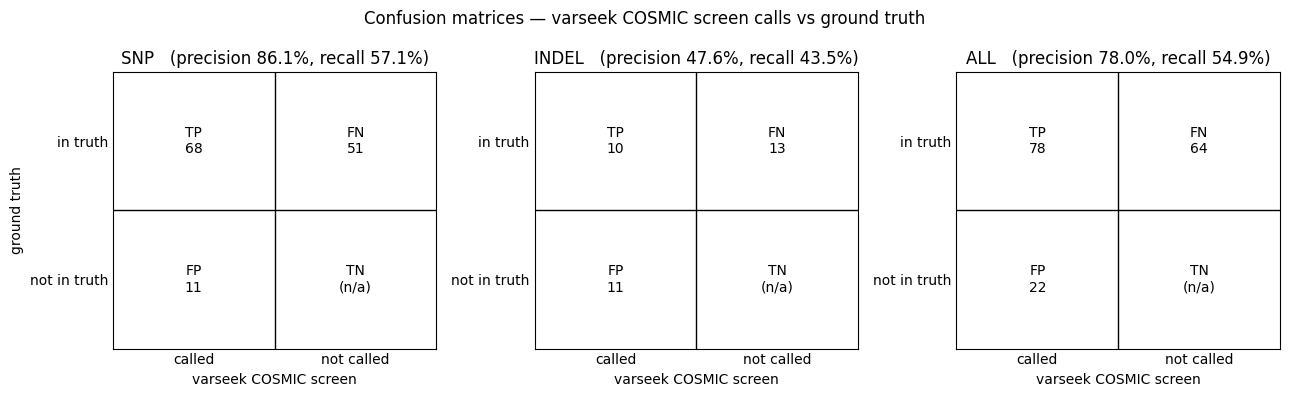

time: 310 ms (started: 2026-08-10 11:55:25 -07:00)


In [26]:
summary_cosmic = pd.read_csv(summary_csv_cosmic)
cols = ["Type", "Filter", "TRUTH.TOTAL", "TRUTH.TP", "TRUTH.FN", "QUERY.TOTAL", "QUERY.FP",
        "METRIC.Recall", "METRIC.Precision", "METRIC.F1_Score"]
display(summary_cosmic[summary_cosmic["Filter"] == "PASS"][cols].reset_index(drop=True))
print("\nTRUTH = GIAB HG001 v4.2.1 (chr20, high-confidence) restricted to COSMIC v104 variants; "
      "QUERY = varseek COSMIC-screen calls")

varseek_cosmic_cms = plot_confusion_matrices(summary_csv_cosmic, tool="varseek COSMIC screen")

In [27]:
# =========================================================================
# Why is the screen's precision so low? Are the false positives thin evidence -- which a
# higher read threshold would clear -- or something depth cannot separate?
#
# hap.py annotates every record of its output VCF with FORMAT/BD (TP / FP / UNK) on the QUERY
# sample, so each call can be joined back to the read support its VCRS actually received.
# SNVs only: they are ~90% of the false positives, and their VCF representation is untouched by
# normalization, so the (POS, REF, ALT) join back to the HGVS variant names is exact.
# =========================================================================
happy_annotated_vcf = os.path.join(happy_out, "varseek_cosmic_vs_giab_truth.vcf.gz")

snv_support = {}
for name, count in zip(adata_vcrs_cosmic.var_names, vcrs_counts_cosmic):
    if count < min_supporting_reads:
        continue
    for v in str(name).split(";"):
        hit = re.match(r"^20:g\.(\d+)([ACGT]+)>([ACGT]+)$", v)
        if hit:
            key = (int(hit.group(1)), hit.group(2), hit.group(3))
            snv_support[key] = max(count, snv_support.get(key, 0))

support = {"TP": [], "FP": []}
with gzip.open(happy_annotated_vcf, "rt") as fh:
    for line in fh:
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split("\t")
        query = dict(zip(f[8].split(":"), f[10].split(":")))   # sample 2 of the hap.py VCF = query
        if query.get("BVT") != "SNP" or query.get("BD") not in ("TP", "FP"):
            continue
        count = snv_support.get((int(f[1]), f[3], f[4]))
        if count:
            support[query["BD"]].append(count)

for label in ("TP", "FP"):
    arr = np.array(support[label])
    print(f"{label} SNVs: n={len(arr):4d}   median reads={np.median(arr):6.0f}   "
          f"<=10 reads: {100 * np.mean(arr <= 10):4.1f}%   max reads={arr.max():,.0f}")

print(f"\nSNP precision if the {min_supporting_reads}-read call threshold were raised:")
for thr in (min_supporting_reads, 5, 10, 20, 30):
    n_tp = int((np.array(support["TP"]) >= thr).sum())
    n_fp = int((np.array(support["FP"]) >= thr).sum())
    print(f"  >= {thr:2d} reads : TP={n_tp:4d}  FP={n_fp:4d}  precision={100 * n_tp / max(n_tp + n_fp, 1):5.1f}%")

TP SNVs: n=  48   median reads=    13   <=10 reads: 31.2%   max reads=27
FP SNVs: n=   8   median reads=     4   <=10 reads: 100.0%   max reads=10

SNP precision if the 3-read call threshold were raised:
  >=  3 reads : TP=  48  FP=   8  precision= 85.7%
  >=  5 reads : TP=  47  FP=   2  precision= 95.9%
  >= 10 reads : TP=  34  FP=   1  precision= 97.1%
  >= 20 reads : TP=   7  FP=   0  precision=100.0%
  >= 30 reads : TP=   0  FP=   0  precision=  0.0%
time: 299 ms (started: 2026-08-10 11:55:25 -07:00)


**Takeaway.** Over the variants it was given a chance to find, the screen recovers most of them —
**78% of SNPs and 96% of indels** of the GIAB ∩ COSMIC truth — but at a precision far below the de
novo pipeline's (11–23% here vs 98.6–99.3% above). Recall and precision are not symmetric findings:
the recall number says the k-mer screen works, the precision number says the *catalog* needs
filtering.

The false positives are not thin evidence that a stricter threshold would clear. Their median read
support is several times that of the true positives, and raising the call threshold makes precision
*worse*, not better — the deepest calls are the most wrong. That is the signature of VCRSs pulling in
wild-type reads at full coverage rather than of sampling noise, which is precisely what the
`remove_alignment_to_reference` d-list in `vk ref` exists to remove; it was switched off here to
match the de novo build above. The de novo pipeline never needed it, because its candidate set comes
from the reads and a VCRS only exists where a variant was actually observed. A catalog screen has no
such protection: it carries 1.45 M VCRSs, essentially all of which are absent from this sample. So
the d-list — against the *calling* assembly, as the d-list section above establishes — is the
load-bearing filter in genotyping mode rather than the optional one it is in de novo mode.